In [1]:
%run ../run_config_project.py
show_env()

BASE DIRECTORY (FD_BASE): /hpc/group/igvf/kk319
REPO DIRECTORY (FD_REPO): /hpc/group/igvf/kk319/repo
WORK DIRECTORY (FD_WORK): /hpc/group/igvf/kk319/work
DATA DIRECTORY (FD_DATA): /hpc/group/igvf/kk319/data


You are working with      IGVF BlueSTARR
PATH OF PROJECT (FD_PRJ): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR
PROJECT RESULTS (FD_RES): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results
PROJECT SCRIPTS (FD_EXE): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/scripts
PROJECT DATA    (FD_DAT): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/data
PROJECT NOTE    (FD_NBK): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/notebooks
PROJECT DOCS    (FD_DOC): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/docs
PROJECT LOG     (FD_LOG): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/log
PROJECT REF     (FD_REF): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/references



In [13]:
import numpy as np
import matplotlib.pyplot as plt
from motifdelta.scan import scan_motif_both_strands

# ----------------------------------------------------------
# 1) Load motif and its calibration threshold
# ----------------------------------------------------------
FP_LODS = "/hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results/analysis_variant_motif_richard/JASPAR2024_CORE_vertebrates_non-redundant.lods.npz"
FP_PMAP = "/hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results/analysis_variant_motif_richard/JASPAR2024_CORE_vertebrates_non-redundant.pmap.npz"
MOTIF_ID = "MA0099.4 FOS::JUN"

lods = np.load(FP_LODS, allow_pickle=True)["lods"].item()
arr_lod = lods[MOTIF_ID]
motif_len = arr_lod.shape[0]

# get T_bind from PMAP
obj_pmap = np.load(FP_PMAP, allow_pickle=True)
Tbind = float(obj_pmap["dct_results"].item()[MOTIF_ID]["num_Tbind"])
print(f"Motif {MOTIF_ID} | length={motif_len} | T_bind={Tbind:.2f} bits")

Motif MA0099.4 FOS::JUN | length=9 | T_bind=5.96 bits


In [14]:
# --- 1) Construct background sequence (C-rich 71 bp) ---
L = 71
center = L // 2
seq_tmp = "C" * L

# --- 2) Create alt allele containing a perfect AP-1 motif at center ---
# Use the consensus TGACTCA (typical FOS::JUN core)
motif_seq_obs = "ATGACTCAT"
motif_seq_ubs = "ATGAGTCAT"
half = len(motif_seq_obs) // 2
start = center - half
end   = start + len(motif_seq_obs)
seq_ref = seq_tmp[:start] + motif_seq_obs + seq_tmp[end:]
seq_alt = seq_tmp[:start] + motif_seq_ubs + seq_tmp[end:]

print(seq_ref)
print(seq_alt)
print(seq_ref[34:37])
print(seq_alt[34:37])

CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCATGACTCATCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC
CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCATGAGTCATCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC
ACT
AGT


In [15]:
# ----------------------------------------------------------
# 3) Scan both alleles (forward + reverse)
# ----------------------------------------------------------
f_ref, r_ref = scan_motif_both_strands(seq_ref, arr_lod)
f_alt, r_alt = scan_motif_both_strands(seq_alt, arr_lod)

# pad to fixed 71 bp
def pad_to_len(x, L=71):
    if len(x) < L:
        x = np.pad(x, (0, L - len(x)), constant_values=np.nan)
    return x

f_ref, r_ref = pad_to_len(f_ref, L), pad_to_len(r_ref, L)
f_alt, r_alt = pad_to_len(f_alt, L), pad_to_len(r_alt, L)

# ----------------------------------------------------------
# 4) Δ computation
# ----------------------------------------------------------
d_f = f_alt - f_ref
d_r = r_alt - r_ref

# ----------------------------------------------------------
# 5) Logistic weight (score-space)
# ----------------------------------------------------------
def logistic_weight(max_score, T, k=1.0):
    z = -(max_score - T) / k
    z = np.clip(z, -60, 60)
    return 1.0 / (1.0 + np.exp(z))

# per-position motif evidence (max of ref/alt)
stack_f = np.vstack([f_ref, f_alt])
stack_r = np.vstack([r_ref, r_alt])
mask_valid_f = np.any(np.isfinite(stack_f), axis=0)
mask_valid_r = np.any(np.isfinite(stack_r), axis=0)

m_f = np.full(L, np.nan)
m_r = np.full(L, np.nan)
m_f[mask_valid_f] = np.nanmax(stack_f[:, mask_valid_f], axis=0)
m_r[mask_valid_r] = np.nanmax(stack_r[:, mask_valid_r], axis=0)

w_f = np.full(L, np.nan)
w_r = np.full(L, np.nan)
w_f[mask_valid_f] = logistic_weight(m_f[mask_valid_f], Tbind, k=1.0)
w_r[mask_valid_r] = logistic_weight(m_r[mask_valid_r], Tbind, k=1.0)

dw_f = w_f * d_f
dw_r = w_r * d_r

In [23]:
x = np.arange(L)
#x = np.arange(L) - center

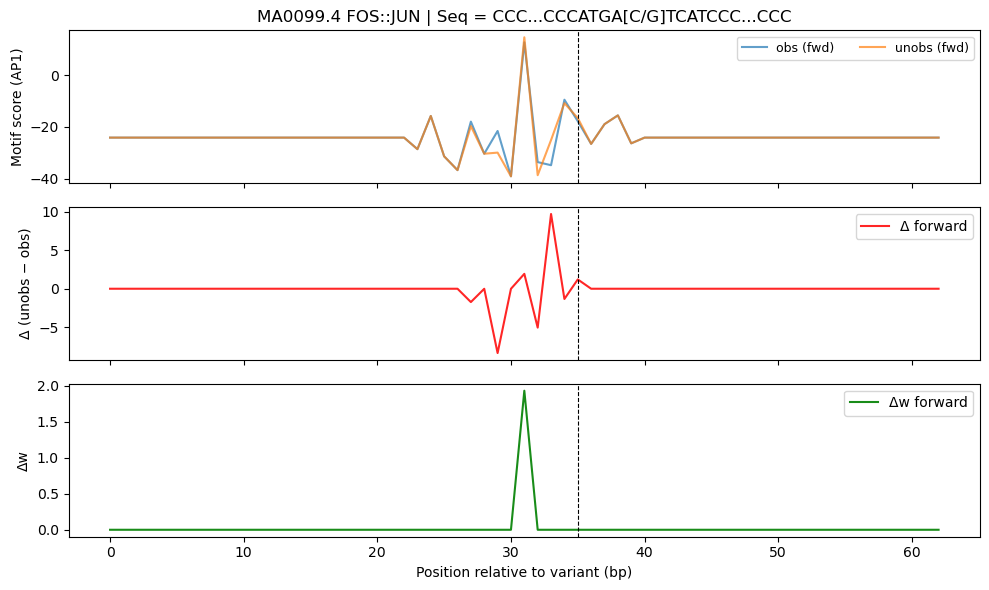

In [26]:
fig, axes = plt.subplots(2 if Tbind is None else 3, 1, figsize=(10, 6), sharex=True)

ax = axes[0]
ax.plot(x, f_ref, alpha=0.7, label="obs (fwd)")
ax.plot(x, f_alt, alpha=0.7, label="unobs (fwd)")
#ax.plot(x, r_ref, lw=0.8, alpha=0.7, label="ref (rev)")
#ax.plot(x, r_alt, lw=0.8, alpha=0.7, label="alt (rev)")
#ax.axvline(0, color="k", ls="--", lw=0.8)
ax.axvline(35, color="k", ls="--", lw=0.8)
ax.set_ylabel("Motif score (AP1)")
ax.legend(ncol=2, fontsize=9)
ax.set_title(f"{MOTIF_ID} | Seq = CCC...CCCATGA[C/G]TCATCCC...CCC")

ax = axes[1]
ax.plot(x, d_f, label="Δ forward", alpha=0.85, c = "red")
#ax.plot(x, d_r, label="Δ reverse", alpha=0.85)
#ax.axvline(0, color="k", ls="--", lw=0.8)
ax.axvline(35, color="k", ls="--", lw=0.8)
ax.set_ylabel("Δ (unobs − obs)")
#ax.set_title(f"{MOTIF_NAME} | 71bp centered variant C -> T")
ax.legend()

if Tbind is not None:
    ax = axes[2]
    ax.plot(x, dw_f, label="Δw forward", alpha=0.9, c = "green")
    #ax.plot(x, dw_r, label="Δw reverse", alpha=0.9)
    #ax.axhline(0, color="k", lw=0.6)
    #ax.axvline(0, color="k", ls="--", lw=0.8)
    ax.axvline(35, color="k", ls="--", lw=0.8)
    ax.set_ylabel("Δw")
    ax.set_xlabel("Position relative to variant (bp)")
    ax.legend()
else:
    axes[1].set_xlabel("Position relative to variant (bp)")

plt.tight_layout()
plt.show()

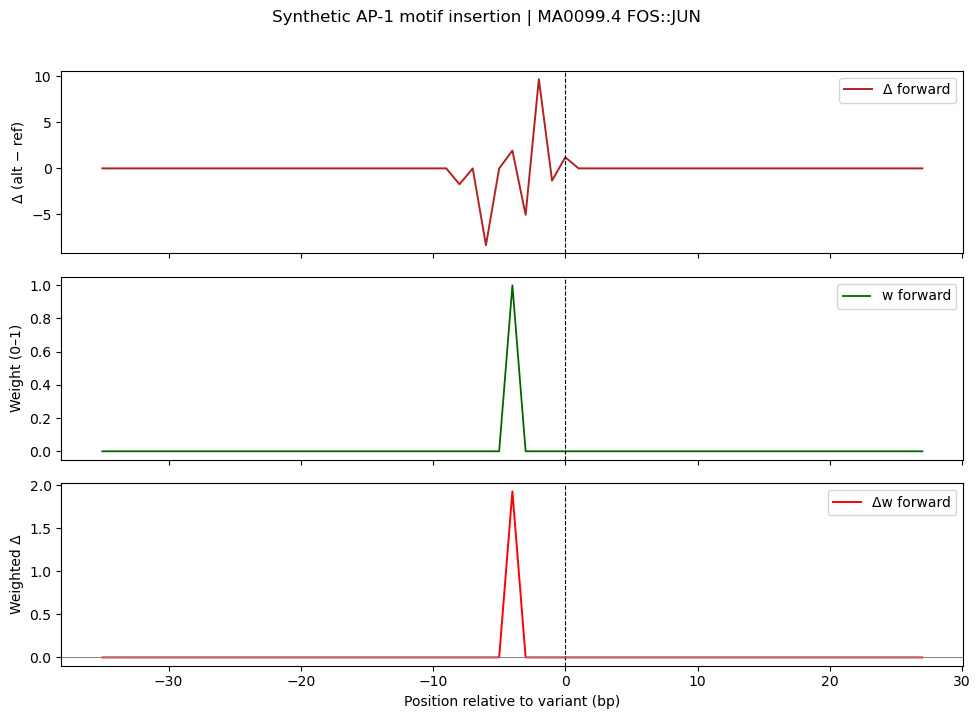

In [17]:
# ----------------------------------------------------------
# 6) Plot Δ, weight, and weighted Δ
# ----------------------------------------------------------
x = np.arange(L) - center

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

# Δ
axes[0].plot(x, d_f, color="firebrick", lw=1.4, label="Δ forward")
#axes[0].plot(x, d_r, color="royalblue", lw=1.4, alpha=0.7, label="Δ reverse")
axes[0].axvline(0, color="k", ls="--", lw=0.8)
axes[0].set_ylabel("Δ (alt − ref)")
axes[0].legend()

# weight
axes[1].plot(x, w_f, color="darkgreen", lw=1.3, label="w forward")
#axes[1].plot(x, w_r, color="olive", lw=1.3, alpha=0.7, label="w reverse")
axes[1].axvline(0, color="k", ls="--", lw=0.8)
axes[1].set_ylabel("Weight (0–1)")
axes[1].legend()

# Δw
axes[2].plot(x, dw_f, color="red", lw=1.4, label="Δw forward")
#axes[2].plot(x, dw_r, color="blue", lw=1.4, alpha=0.7, label="Δw reverse")
axes[2].axvline(0, color="k", ls="--", lw=0.8)
axes[2].axhline(0, color="gray", lw=0.7)
axes[2].set_ylabel("Weighted Δ")
axes[2].set_xlabel("Position relative to variant (bp)")
axes[2].legend()

plt.suptitle(f"Synthetic AP-1 motif insertion | {MOTIF_ID}", y=1.02)
plt.tight_layout()
plt.show()



In [2]:
import numpy as np
import matplotlib.pyplot as plt
from motifdelta.scan import scan_motif_both_strands

# --- Load the motif log-odds matrix ---
FP_LODS = "/hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results/analysis_variant_motif_richard/JASPAR2024_CORE_vertebrates_non-redundant.lods.npz"
MOTIF_ID = "MA0099.4 FOS::JUN"

lods = np.load(FP_LODS, allow_pickle=True)["lods"].item()
arr_lod = lods[MOTIF_ID]
motif_len = arr_lod.shape[0]

In [ ]:
# --- 2) Load motif log-odds (and optional PMAP with Tbind) ---
obj_lods = np.load(FP_LODS, allow_pickle=True)
dct_lods = obj_lods["lods"].item()
arr_lod_Wx4 = dct_lods[MOTIF_NAME]  # shape (W,4)

try:
    obj_pmap = np.load(FP_PMAP, allow_pickle=True)
    dct_pmap = obj_pmap["dct_results"].item()
    Tbind = float(dct_pmap[MOTIF_NAME]["num_Tbind"])
except Exception:
    dct_pmap = None
    Tbind = None

In [9]:
# --- 1) Construct background sequence (C-rich 71 bp) ---
L = 71
center = L // 2
seq_tmp = "C" * L

# --- 2) Create alt allele containing a perfect AP-1 motif at center ---
# Use the consensus TGACTCA (typical FOS::JUN core)
motif_seq_obs = "ATGACTCAT"
motif_seq_ubs = "ATGAGTCAT"
half = len(motif_seq_obs) // 2
start = center - half
end   = start + len(motif_seq_obs)
seq_ref = seq_tmp[:start] + motif_seq_obs + seq_tmp[end:]
seq_alt = seq_tmp[:start] + motif_seq_ubs + seq_tmp[end:]

print(seq_ref)
print(seq_alt)
print(seq_ref[34:37])
print(seq_alt[34:37])

CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCATGACTCATCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC
CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCATGAGTCATCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC
ACT
AGT


In [10]:
print(f"Inserted motif at {start}-{end} (center {center})")
print(seq_alt)

# --- 3) Scan both alleles ---
f_ref, r_ref = scan_motif_both_strands(seq_ref, arr_lod)
f_alt, r_alt = scan_motif_both_strands(seq_alt, arr_lod)

# --- 4) Align lengths & compute Δ ---
def pad_to_len(x, L=71):
    if len(x) < L:
        x = np.pad(x, (0, L - len(x)), constant_values=np.nan)
    return x

f_ref, f_alt = pad_to_len(f_ref, L), pad_to_len(f_alt, L)
r_ref, r_alt = pad_to_len(r_ref, L), pad_to_len(r_alt, L)
d_f = f_alt - f_ref
d_r = r_alt - r_ref

# --- 5) Plot ---
x = np.arange(L) - center

Inserted motif at 31-40 (center 35)
CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCATGAGTCATCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC


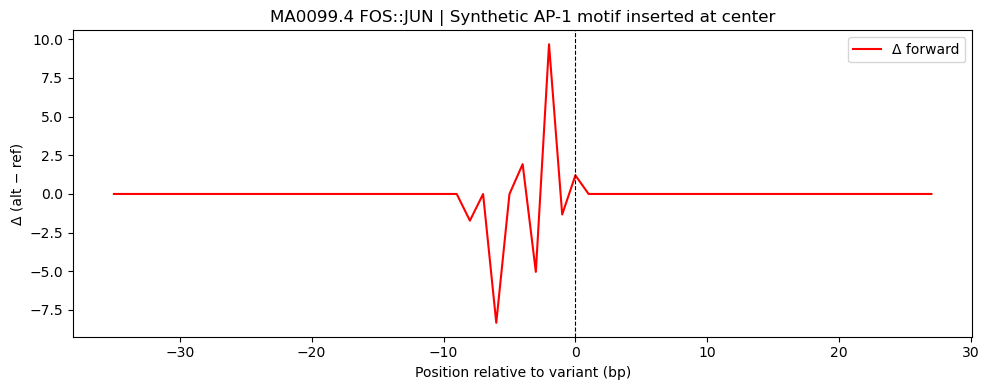

In [12]:
plt.figure(figsize=(10,4))
plt.plot(x, d_f, label="Δ forward", color="red")
#plt.plot(x, d_r, label="Δ reverse", color="blue", alpha=0.6)
plt.axvline(0, color="k", ls="--", lw=0.8)
plt.xlabel("Position relative to variant (bp)")
plt.ylabel("Δ (alt − ref)")
plt.title(f"{MOTIF_ID} | Synthetic AP-1 motif inserted at center")
plt.legend()
plt.tight_layout()
plt.show()